# 06 — ABP: Transition Times and Hyperparameters

## Contrato numérico

The transition is defined as entering to the circle of radius 1/2 and centered in (1,0)

$
\xi(x,y)=-\bigl((x-1)^2+y^2\bigr),
$

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
import json
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

from stage_escape.abp_abf import ABPMetaDynamics, Potential, TransitionDetector
from stage_escape.result_io import load_result, save_result

RUN_MODE = "full"       # "smoke", "full" o "load"
REUSE_CACHE = True
N_JOBS = -1
BASE_SEED = 20260805
SAVE_FIGURES = False

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Ejecuta Jupyter dentro del repositorio STAGE.")

REPO_ROOT = find_repo_root()
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "notebook_06"
FIGURE_DIR = ARTIFACT_DIR / "figures"
RESULT_DIR = ARTIFACT_DIR / "results"
SUMMARY_PATH = ARTIFACT_DIR / f"abp_sweep_{RUN_MODE}.csv"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

def finish_figure(fig, filename: str) -> None:
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / f"{filename}.png", bbox_inches="tight")
        fig.savefig(FIGURE_DIR / f"{filename}.pdf", bbox_inches="tight")
    plt.show()

In [2]:
def entropic_switch_value(position: np.ndarray) -> float:
    x, y = np.asarray(position, dtype=float)
    x2 = x**2
    y_shift_2 = (y - 1.0 / 3.0) ** 2
    return float(
        3.0
        * np.exp(-x2)
        * (np.exp(-y_shift_2) - np.exp(-(y - 5.0 / 3.0) ** 2))
        - 5.0
        * np.exp(-y**2)
        * (np.exp(-(x - 1.0) ** 2) + np.exp(-(x + 1.0) ** 2))
        + 0.2 * x2**2
        + 0.2 * y_shift_2**2
    )

def entropic_switch_gradient(position: np.ndarray, h: float = 1.0e-5) -> np.ndarray:
    position = np.asarray(position, dtype=float)
    gradient = np.empty(2, dtype=float)
    for coordinate in range(2):
        increment = np.zeros(2, dtype=float)
        increment[coordinate] = h
        gradient[coordinate] = (
            entropic_switch_value(position + increment)
            - entropic_switch_value(position - increment)
        ) / (2.0 * h)
    return gradient

POTENTIAL = Potential(
    dimension=2,
    function=entropic_switch_value,
    first_derivative=entropic_switch_gradient,
)

TARGET_CENTER = np.array([1.0, 0.0])
TARGET_RADIUS = 0.5

def collective_variable(position: np.ndarray) -> float:
    displacement = np.asarray(position, dtype=float) - TARGET_CENTER
    return -float(displacement @ displacement)

DETECTOR = TransitionDetector(
    collective_variable=collective_variable,
    threshold=-(TARGET_RADIUS**2),
    direction="above",
)

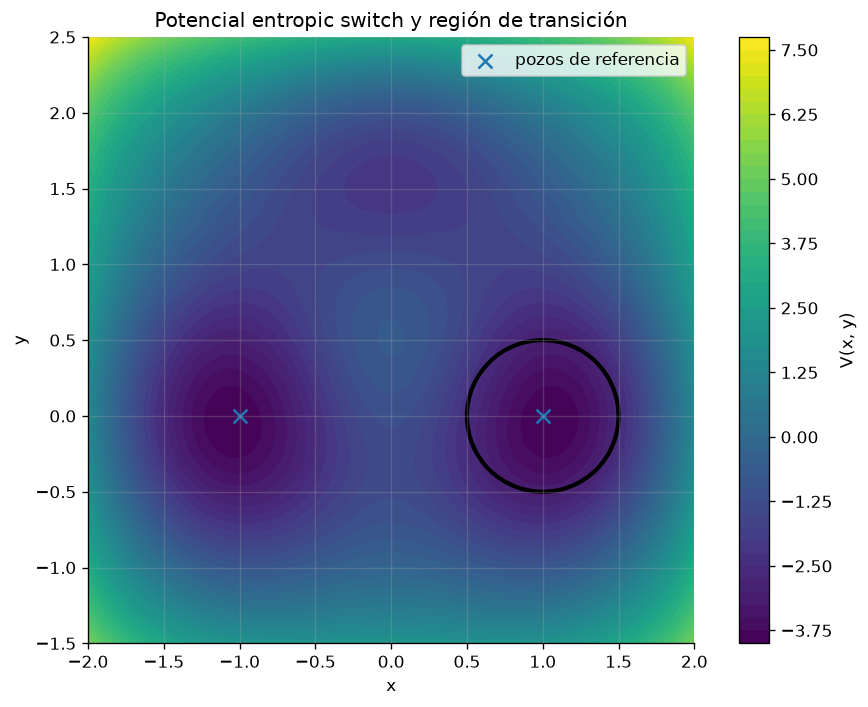

In [3]:
x_grid = np.linspace(-2.0, 2.0, 240)
y_grid = np.linspace(-1.5, 2.5, 240)
X, Y = np.meshgrid(x_grid, y_grid)
V = np.fromiter(
    (entropic_switch_value(np.array([x, y])) for x, y in zip(X.ravel(), Y.ravel(), strict=True)),
    dtype=float,
    count=X.size,
).reshape(X.shape)

fig, ax = plt.subplots(figsize=(8.0, 6.0))
contour = ax.contourf(X, Y, V, levels=50)
fig.colorbar(contour, ax=ax, label="V(x, y)")
target = plt.Circle(TARGET_CENTER, TARGET_RADIUS, fill=False, linewidth=2.5)
ax.add_patch(target)
ax.scatter([-1.0, 1.0], [0.0, 0.0], marker="x", s=70, label="pozos de referencia")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.set_title("Potencial entropic switch y región de transición")
ax.legend()
finish_figure(fig, "potential_and_target")

In [4]:
@dataclass(frozen=True)
class ABPCase:
    label: str
    W: float
    sigma: float
    deposition_stride: int
    delta_t: float = 2.0e-3
    diffusion: float = 0.3
    max_steps: int = 80_000

def run_abp_case(case: ABPCase, seed: int, *, persist_stem: Path | None = None) -> dict:
    simulation = ABPMetaDynamics(
        deposition_stride=case.deposition_stride,
        transition_detector=DETECTOR,
        delta_t=case.delta_t,
        dimension=2,
        D=case.diffusion,
        initial_position=np.array([-1.0, 0.0]),
        b=POTENTIAL,
        W=case.W,
        sigma=case.sigma,
        seed=seed,
    )

    started = time.perf_counter()
    result = simulation.run(max_steps=case.max_steps)
    cpu_seconds = time.perf_counter() - started

    if persist_stem is not None:
        save_result(result, persist_stem)

    biased_time = result.biased_transition_time
    acceleration = (
        result.reweighted_time / biased_time
        if biased_time is not None and biased_time > 0.0
        else np.nan
    )

    return {
        **asdict(case),
        "seed": seed,
        "transition_detected": result.transition_detected,
        "termination_reason": result.termination_reason,
        "n_steps": result.n_steps,
        "biased_transition_time": np.nan if biased_time is None else biased_time,
        "reweighted_time": result.reweighted_time,
        "acceleration_factor": acceleration,
        "n_centers": len(result.centers),
        "cpu_seconds": cpu_seconds,
    }

REFERENCE_CASE = ABPCase(
    label="reference",
    W=0.10,
    sigma=0.15,
    deposition_stride=50,
    max_steps=80_000 if RUN_MODE == "smoke" else 600_000,
)

representative_stem = RESULT_DIR / "representative_abp"
if REUSE_CACHE and representative_stem.with_suffix(".json").exists():
    representative = load_result(representative_stem)
else:
    representative_simulation = ABPMetaDynamics(
        deposition_stride=REFERENCE_CASE.deposition_stride,
        transition_detector=DETECTOR,
        delta_t=REFERENCE_CASE.delta_t,
        dimension=2,
        D=REFERENCE_CASE.diffusion,
        initial_position=np.array([-1.0, 0.0]),
        b=POTENTIAL,
        W=REFERENCE_CASE.W,
        sigma=REFERENCE_CASE.sigma,
        seed=BASE_SEED,
    )
    representative = representative_simulation.run(
        max_steps=REFERENCE_CASE.max_steps
    )
    save_result(representative, representative_stem)

representative

ABPResult(method='abp', positions=array([[-1.        ,  0.        ],
       [-1.02834694,  0.04714638],
       [-0.97386851,  0.05069438],
       ...,
       [ 1.12574785,  0.51230344],
       [ 1.14135113,  0.48541066],
       [ 1.16225923,  0.45788628]], shape=(8251, 2)), delta_t=0.002, diffusion=0.3, seed=20260805, transition_index=8250, physical_time=1501.3033692848378, termination_reason='transition', metadata=mappingproxy({'dimension': 2, 'deposition_stride': 50, 'cutoff': 5.0}), weights=array([1., 1., 1., ..., 1., 1., 1.], shape=(8251,)), centers=array([[-1.20943938,  0.14928201],
       [-0.95300011, -0.02664584],
       [-1.0653059 , -0.04380151],
       [-0.98738619, -0.19939072],
       [-0.97686989, -0.03026026],
       [-1.05075574,  0.3437043 ],
       [-0.96045513,  0.27383489],
       [-1.02224505,  0.01081706],
       [-1.34293445, -0.01154726],
       [-1.19764407, -0.0671673 ],
       [-1.06451924,  0.15326177],
       [-1.25805181,  0.16337249],
       [-1.35025537,

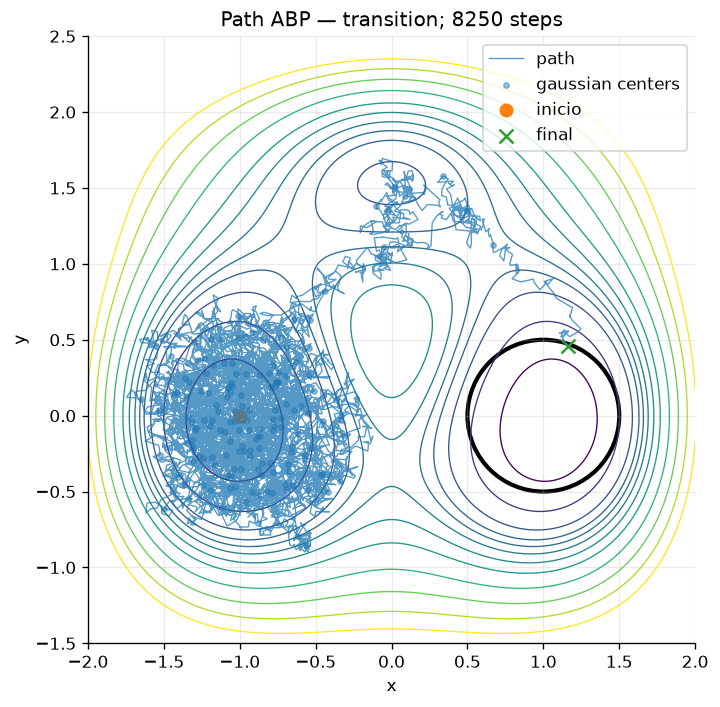

In [7]:
path = representative.positions
fig, ax = plt.subplots(figsize=(8.0, 6.0))
levels = np.quantile(V, np.linspace(0.05, 0.80, 12))
ax.contour(X, Y, V, levels=np.unique(levels), linewidths=0.8)
stride = max(1, len(path) // 10_000)
ax.plot(path[::stride, 0], path[::stride, 1], linewidth=0.8, alpha=0.75, label="path")
if len(representative.centers):
    ax.scatter(
        representative.centers[:, 0],
        representative.centers[:, 1],
        s=10,
        alpha=0.45,
        label="gaussian centers",
    )
ax.add_patch(plt.Circle(TARGET_CENTER, TARGET_RADIUS, fill=False, linewidth=2.5))
ax.scatter(path[0, 0], path[0, 1], marker="o", s=55, label="inicio")
ax.scatter(path[-1, 0], path[-1, 1], marker="x", s=70, label="final")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.set_title(
    f"Path ABP — {representative.termination_reason}; "
    f"{representative.n_steps} steps"
)
ax.legend()
finish_figure(fig, "representative_path")

In [8]:
if RUN_MODE == "smoke":
    repetitions = 4
    W_VALUES = [0.05, 0.10, 0.20]
    SIGMA_VALUES = [0.08, 0.15, 0.25]
    STRIDE_VALUES = [25, 50, 100]
    sweep_max_steps = 80_000
else:
    repetitions = 40
    W_VALUES = np.geomspace(0.02, 0.40, 8)
    SIGMA_VALUES = np.geomspace(0.04, 0.40, 8)
    STRIDE_VALUES = [10, 20, 40, 80, 160, 320]
    sweep_max_steps = 600_000

cases = []
for value in W_VALUES:
    cases.append(
        ABPCase(
            label="W",
            W=float(value),
            sigma=REFERENCE_CASE.sigma,
            deposition_stride=REFERENCE_CASE.deposition_stride,
            max_steps=sweep_max_steps,
        )
    )
for value in SIGMA_VALUES:
    cases.append(
        ABPCase(
            label="sigma",
            W=REFERENCE_CASE.W,
            sigma=float(value),
            deposition_stride=REFERENCE_CASE.deposition_stride,
            max_steps=sweep_max_steps,
        )
    )
for value in STRIDE_VALUES:
    cases.append(
        ABPCase(
            label="deposition_stride",
            W=REFERENCE_CASE.W,
            sigma=REFERENCE_CASE.sigma,
            deposition_stride=int(value),
            max_steps=sweep_max_steps,
        )
    )

if RUN_MODE == "load":
    if not SUMMARY_PATH.exists():
        raise FileNotFoundError(f"No existe el caché {SUMMARY_PATH}.")
    runs = pd.read_csv(SUMMARY_PATH)
elif REUSE_CACHE and SUMMARY_PATH.exists():
    runs = pd.read_csv(SUMMARY_PATH)
else:
    seed_sequence = np.random.SeedSequence(BASE_SEED)
    child_sequences = seed_sequence.spawn(len(cases) * repetitions)
    tasks = []
    cursor = 0
    for case in cases:
        for _ in range(repetitions):
            seed = int(child_sequences[cursor].generate_state(1)[0])
            cursor += 1
            tasks.append((case, seed))

    records = Parallel(n_jobs=N_JOBS)(
        delayed(run_abp_case)(case, seed) for case, seed in tasks
    )
    runs = pd.DataFrame.from_records(records)
    SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
    runs.to_csv(SUMMARY_PATH, index=False)

runs.head()

,label,W,sigma,deposition_stride,delta_t,diffusion,max_steps,seed,transition_detected,termination_reason,n_steps,biased_transition_time,reweighted_time,acceleration_factor,n_centers,cpu_seconds
0,W,0.02,0.15,50,0.002,0.3,600000,1117257062,True,transition,26906,53.812,726.116147,13.493573,538,30.657192
1,W,0.02,0.15,50,0.002,0.3,600000,1739813875,True,transition,29277,58.554,1744.029057,29.784969,585,33.032093
2,W,0.02,0.15,50,0.002,0.3,600000,1419349886,True,transition,44130,88.260,7038.749532,79.750165,882,67.471230
3,W,0.02,0.15,50,0.002,0.3,600000,1077354921,True,transition,27633,55.266,982.447959,17.776715,552,31.362285
4,W,0.02,0.15,50,0.002,0.3,600000,1178390433,True,transition,32631,65.262,2518.410163,38.589227,652,40.993279


In [9]:
def summarize_group(group: pd.DataFrame) -> pd.Series:
    successful = group[group["transition_detected"]]
    return pd.Series(
        {
            "n_runs": len(group),
            "transition_rate": group["transition_detected"].mean(),
            "mean_reweighted_time_success": successful["reweighted_time"].mean(),
            "sem_reweighted_time_success": successful["reweighted_time"].sem(),
            "mean_biased_time_success": successful["biased_transition_time"].mean(),
            "median_acceleration_success": successful["acceleration_factor"].median(),
            "mean_steps": group["n_steps"].mean(),
            "mean_cpu_seconds": group["cpu_seconds"].mean(),
        }
    )

summary = (
    runs.groupby(["label", "W", "sigma", "deposition_stride"], dropna=False)
    .apply(summarize_group)
    .reset_index()
)
summary

,label,W,sigma,deposition_stride,n_runs,transition_rate,mean_reweighted_time_success,sem_reweighted_time_success,mean_biased_time_success,median_acceleration_success,mean_steps,mean_cpu_seconds
0,W,0.020000,0.150000,50,40.0,1.0,1699.371972,272.320504,51.46320,22.193095,25731.600,33.713215
1,W,0.030683,0.150000,50,40.0,1.0,1596.965126,206.653097,39.44820,30.982909,19724.100,22.505441
2,W,0.047071,0.150000,50,40.0,1.0,2160.476057,507.790142,30.15265,33.073566,15076.325,14.984647
3,W,0.072213,0.150000,50,40.0,1.0,2038.188802,422.540631,22.70860,33.295335,11354.300,9.684836
4,W,0.110784,0.150000,50,40.0,1.0,1812.673162,442.799290,16.57790,62.695710,8288.950,6.490015
5,W,0.169956,0.150000,50,40.0,1.0,2697.631269,1041.820361,11.66365,59.052106,5831.825,4.166687
6,W,0.260735,0.150000,50,40.0,1.0,23252.526576,20738.925846,9.89640,82.181736,4948.200,3.373345
7,W,0.400000,0.150000,50,40.0,1.0,16598.914767,7713.922283,6.75545,246.259904,3377.725,2.164721
8,deposition_stride,0.100000,0.150000,10,40.0,1.0,10899.567471,6416.127225,6.27670,173.555341,3138.350,3.075641
9,deposition_stride,0.100000,0.150000,20,40.0,1.0,3627.561206,842.280696,9.65300,133.849260,4826.500,4.278832


In [10]:
successful_reference = runs[
    (runs["label"] == "W")
    & np.isclose(runs["W"], REFERENCE_CASE.W)
    & runs["transition_detected"]
]

if len(successful_reference):
    values = successful_reference["reweighted_time"].to_numpy()
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.hist(values, bins="auto", density=True, alpha=0.55, label="reweighted times")
    mean_value = values.mean()
    if mean_value > 0.0:
        x = np.linspace(0.0, max(values.max(), 3.0 * mean_value), 300)
        ax.plot(x, np.exp(-x / mean_value) / mean_value, label="exponential with sample mean")
    ax.set_xlabel("reweighted physical time")
    ax.set_ylabel("density")
    ax.set_title("Distribution of Successful Transition Times")
    ax.legend()
    finish_figure(fig, "transition_time_distribution")
else:
    print("No transitions found in the reference case; increase max_steps.")

No transitions found in the reference case; increase max_steps.


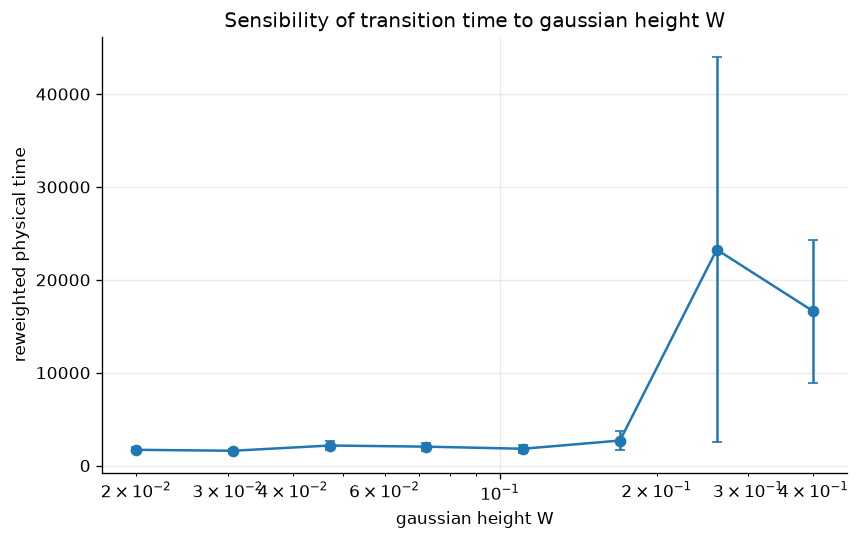

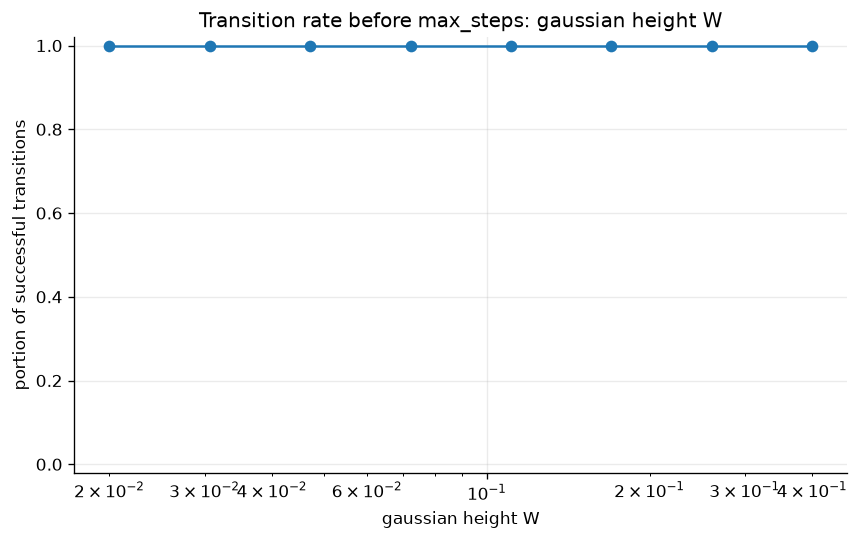

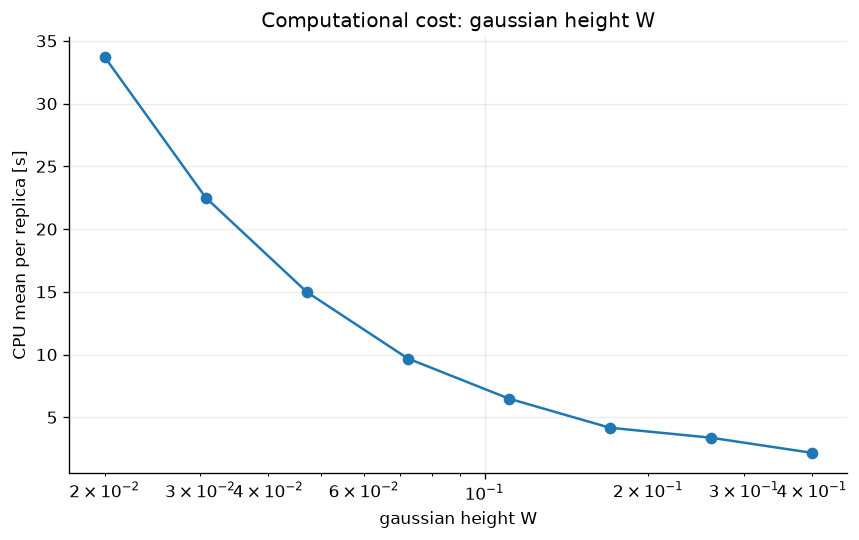

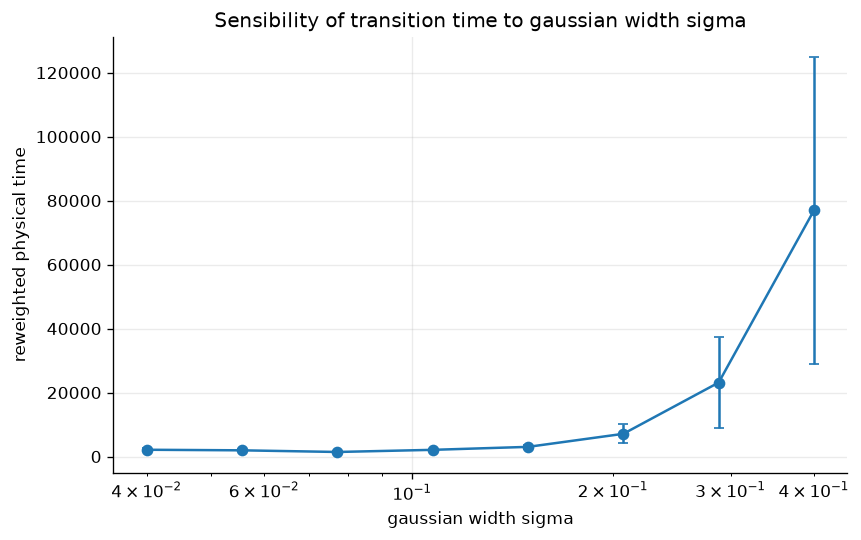

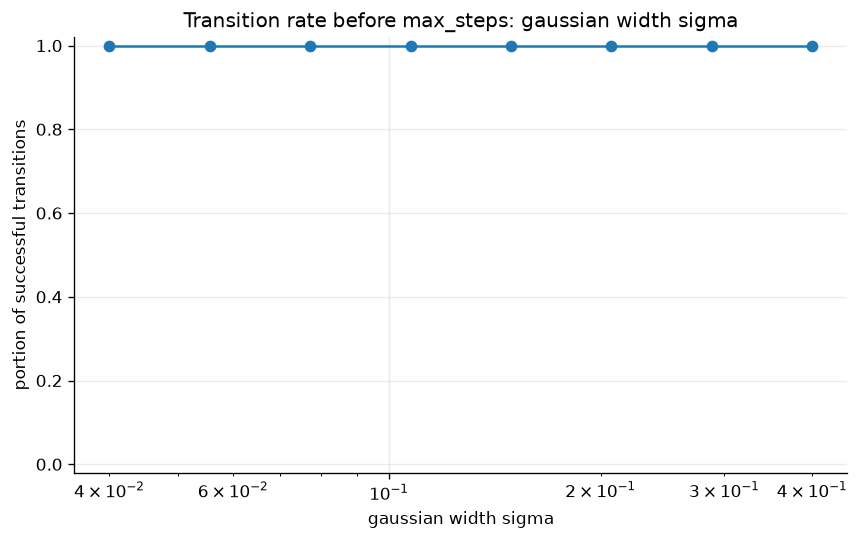

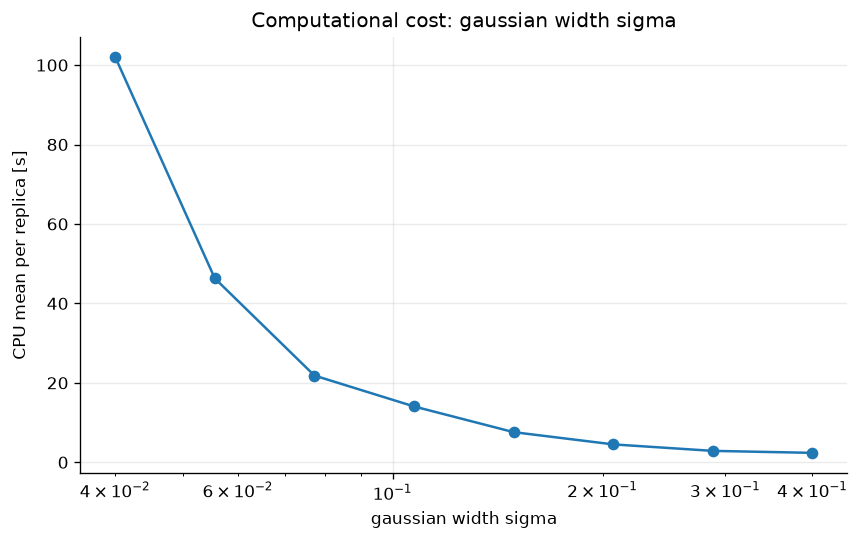

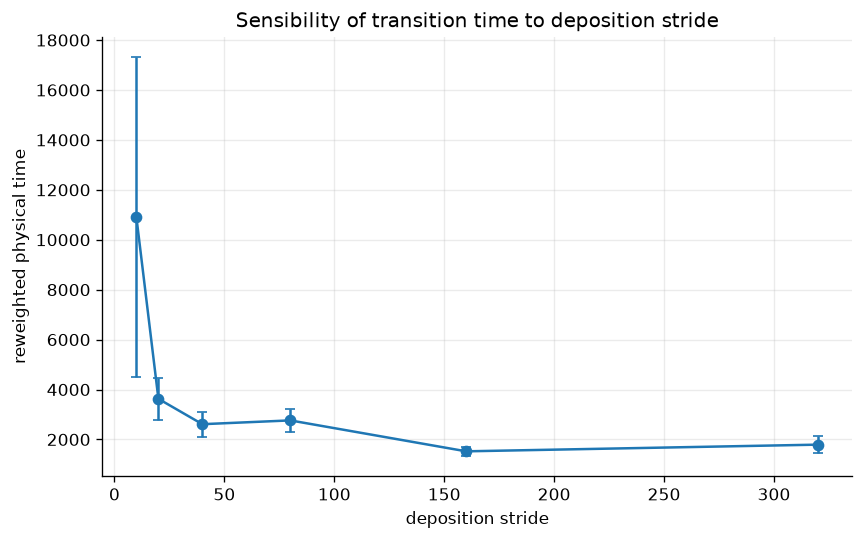

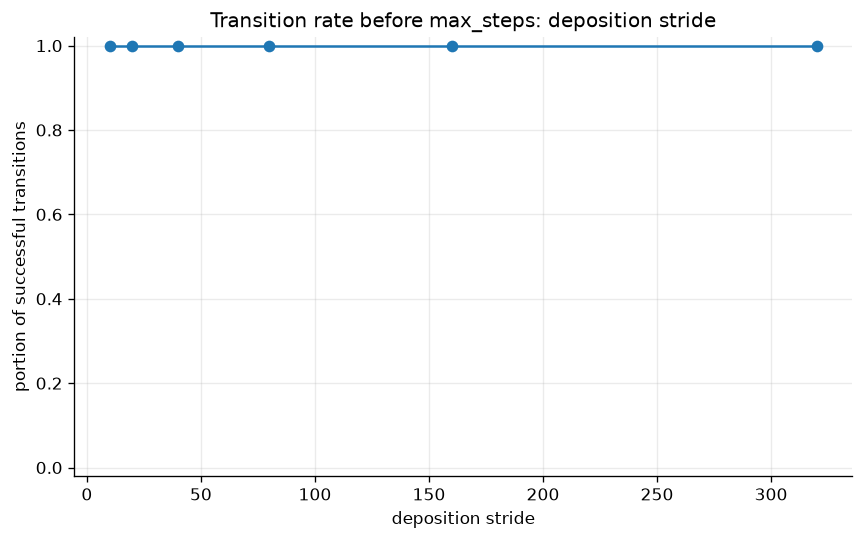

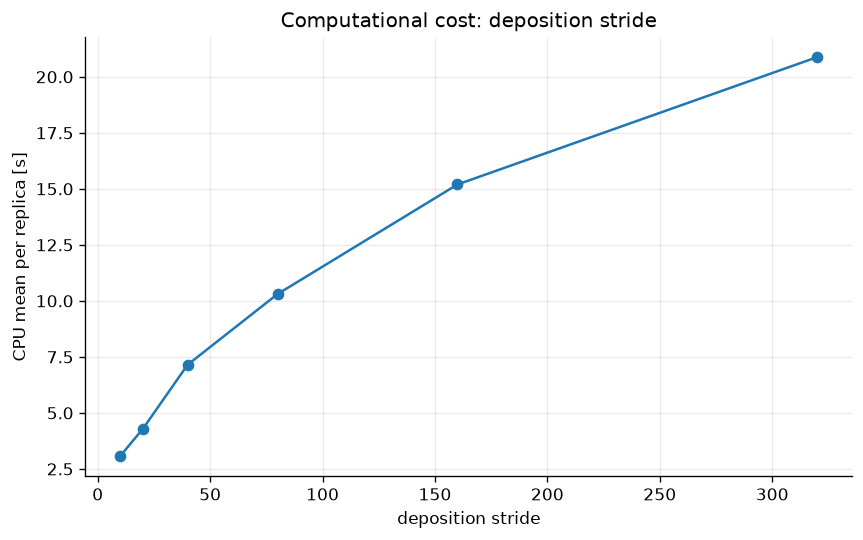

In [11]:
parameter_specs = {
    "W": ("W", "gaussian height W"),
    "sigma": ("sigma", "gaussian width sigma"),
    "deposition_stride": ("deposition_stride", "deposition stride"),
}

for label, (column, xlabel) in parameter_specs.items():
    subset = summary[summary["label"] == label].sort_values(column)

    fig, ax = plt.subplots(figsize=(7.3, 4.6))
    ax.errorbar(
        subset[column],
        subset["mean_reweighted_time_success"],
        yerr=subset["sem_reweighted_time_success"],
        marker="o",
        capsize=3,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("reweighted physical time")
    ax.set_title(f"Sensibility of transition time to {xlabel}")
    if label in {"W", "sigma"}:
        ax.set_xscale("log")
    finish_figure(fig, f"{label}_transition_time")

    fig, ax = plt.subplots(figsize=(7.3, 4.6))
    ax.plot(subset[column], subset["transition_rate"], marker="o")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("portion of successful transitions")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"Transition rate before max_steps: {xlabel}")
    if label in {"W", "sigma"}:
        ax.set_xscale("log")
    finish_figure(fig, f"{label}_success_rate")

    fig, ax = plt.subplots(figsize=(7.3, 4.6))
    ax.plot(subset[column], subset["mean_cpu_seconds"], marker="o")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("CPU mean per replica [s]")
    ax.set_title(f"Computational cost: {xlabel}")
    if label in {"W", "sigma"}:
        ax.set_xscale("log")
    finish_figure(fig, f"{label}_cpu")